In [1]:
# Author: Remi Flamary <remi.flamary@polytechnique.edu>
#
# License: MIT License

# sphinx_gallery_thumbnail_number = 3

import numpy as np
import matplotlib.pyplot as pl
import torch
import ot
import ot.plot

### Data generation

In [2]:
torch.manual_seed(1)

n_source_samples = 100
n_target_samples = 100
theta = 2 * np.pi / 20
noise_level = 0.1

Xs, ys = ot.datasets.make_data_classif("gaussrot", n_source_samples, nz=noise_level)
Xt, yt = ot.datasets.make_data_classif(
    "gaussrot", n_target_samples, theta=theta, nz=noise_level
)

# one of the target mode changes its variance (no linear mapping)
Xt[yt == 2] *= 3
Xt = Xt + 4

### Plot data

Text(0.5, 1.0, 'Source and target distributions')

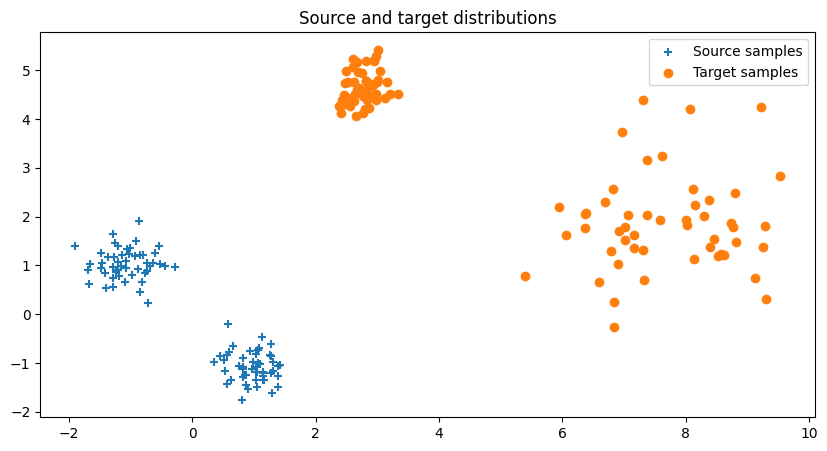

In [3]:
pl.figure(1, (10, 5))
pl.clf()
pl.scatter(Xs[:, 0], Xs[:, 1], marker="+", label="Source samples")
pl.scatter(Xt[:, 0], Xt[:, 1], marker="o", label="Target samples")
pl.legend(loc=0)
pl.title("Source and target distributions")

### Convert data to torch tensors

In [4]:
xs = torch.tensor(Xs)
xt = torch.tensor(Xt)

### Estimating dual variables for entropic OT

Iter:   0, loss=0.20204949002247305
Iter:  10, loss=-19.585253404760596
Iter:  20, loss=-31.548194266559605
Iter:  30, loss=-35.53256389036442
Iter:  40, loss=-38.86029835138012
Iter:  50, loss=-40.203694896671806
Iter:  60, loss=-40.91977295065613
Iter:  70, loss=-41.2346394750464
Iter:  80, loss=-41.395420777732724
Iter:  90, loss=-41.44294239127937
Iter: 100, loss=-41.46323470053103
Iter: 110, loss=-41.4698146955485
Iter: 120, loss=-41.47215824356772
Iter: 130, loss=-41.47357747400773
Iter: 140, loss=-41.47434027423853
Iter: 150, loss=-41.47474661759745
Iter: 160, loss=-41.47502542675134
Iter: 170, loss=-41.475236578593396
Iter: 180, loss=-41.47540060188051
Iter: 190, loss=-41.47553242288903


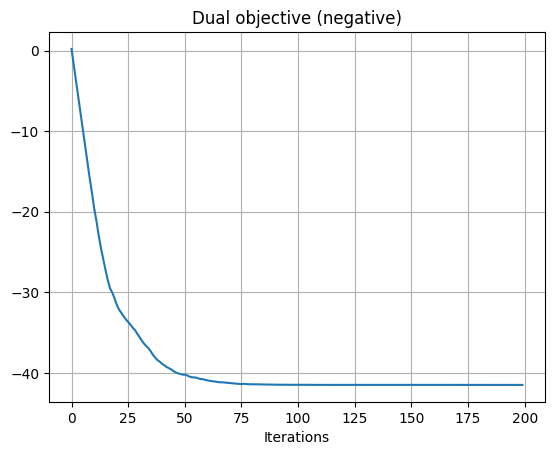

In [5]:
u = torch.randn(n_source_samples, requires_grad=True)
v = torch.randn(n_source_samples, requires_grad=True)

reg = 0.5

optimizer = torch.optim.Adam([u, v], lr=1)

# number of iteration
n_iter = 200


losses = []

for i in range(n_iter):
    # generate noise samples

    # minus because we maximize the dual loss
    loss = -ot.stochastic.loss_dual_entropic(u, v, xs, xt, reg=reg)
    losses.append(float(loss.detach()))

    if i % 10 == 0:
        print("Iter: {:3d}, loss={}".format(i, losses[-1]))

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()


pl.figure(2)
pl.plot(losses)
pl.grid()
pl.title("Dual objective (negative)")
pl.xlabel("Iterations")

Ge = ot.stochastic.plan_dual_entropic(u, v, xs, xt, reg=reg)

### Plot the estimated entropic OT plan

Text(0.5, 1.0, 'Source and target distributions')

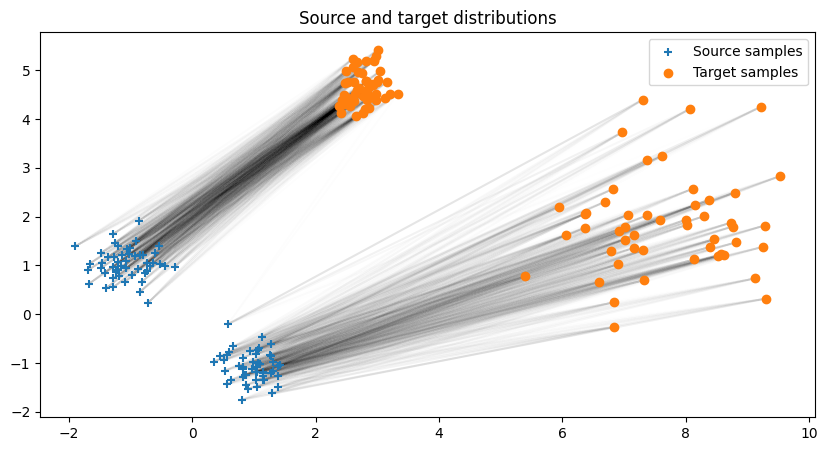

In [6]:
pl.figure(3, (10, 5))
pl.clf()
ot.plot.plot2D_samples_mat(Xs, Xt, Ge.detach().numpy(), alpha=0.1)
pl.scatter(Xs[:, 0], Xs[:, 1], marker="+", label="Source samples", zorder=2)
pl.scatter(Xt[:, 0], Xt[:, 1], marker="o", label="Target samples", zorder=2)
pl.legend(loc=0)
pl.title("Source and target distributions")

### Estimating dual variables for quadratic OT

Iter:   0, loss=-0.0018442196020623663
Iter:  10, loss=-19.57266175798773
Iter:  20, loss=-31.291514576775413
Iter:  30, loss=-35.18820668770923
Iter:  40, loss=-38.64457943791056
Iter:  50, loss=-39.96178217885699
Iter:  60, loss=-40.683471712070066
Iter:  70, loss=-41.078733386116504
Iter:  80, loss=-41.23789304746057
Iter:  90, loss=-41.32106132035861
Iter: 100, loss=-41.343001011341386
Iter: 110, loss=-41.35158501150712
Iter: 120, loss=-41.35328304235439
Iter: 130, loss=-41.3541555679338
Iter: 140, loss=-41.354555842193115
Iter: 150, loss=-41.35470051848999
Iter: 160, loss=-41.35478817296505
Iter: 170, loss=-41.35484454269107
Iter: 180, loss=-41.35488537134416
Iter: 190, loss=-41.354919159898444


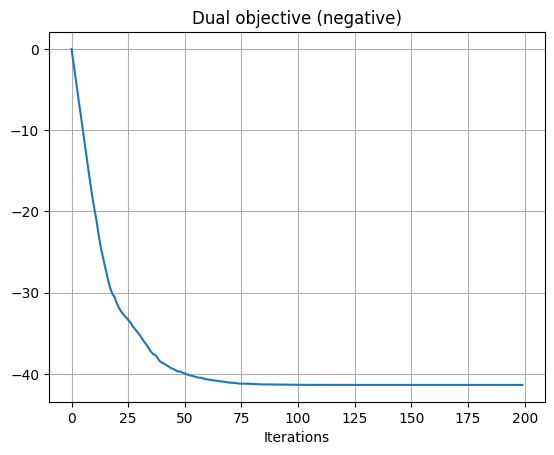

In [7]:
u = torch.randn(n_source_samples, requires_grad=True)
v = torch.randn(n_source_samples, requires_grad=True)

reg = 0.01

optimizer = torch.optim.Adam([u, v], lr=1)

# number of iteration
n_iter = 200


losses = []


for i in range(n_iter):
    # generate noise samples

    # minus because we maximize the dual loss
    loss = -ot.stochastic.loss_dual_quadratic(u, v, xs, xt, reg=reg)
    losses.append(float(loss.detach()))

    if i % 10 == 0:
        print("Iter: {:3d}, loss={}".format(i, losses[-1]))

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()


pl.figure(4)
pl.plot(losses)
pl.grid()
pl.title("Dual objective (negative)")
pl.xlabel("Iterations")

Gq = ot.stochastic.plan_dual_quadratic(u, v, xs, xt, reg=reg)

### Plot the estimated quadratic OT plan

Text(0.5, 1.0, 'OT plan with quadratic regularization')

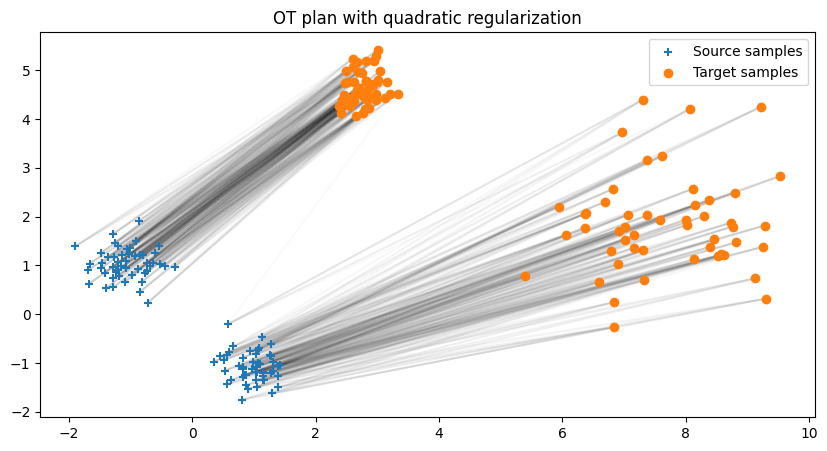

In [8]:
pl.figure(5, (10, 5))
pl.clf()
ot.plot.plot2D_samples_mat(Xs, Xt, Gq.detach().numpy(), alpha=0.1)
pl.scatter(Xs[:, 0], Xs[:, 1], marker="+", label="Source samples", zorder=2)
pl.scatter(Xt[:, 0], Xt[:, 1], marker="o", label="Target samples", zorder=2)
pl.legend(loc=0)
pl.title("OT plan with quadratic regularization")